# Mandatory Assignment 1

#### Part II: Convolutional Neural Networks

***

Please see the description of the assignment in the README file (section 2) <br>
**Guide notebook**: [material/cnns_pytorch.ipynb](material/cnns_pytorch.ipynb)

Table of contents:
1. Activate GPU
2. Load data
3. Inspect data
4. Convolutional neural network (**Where you will implement the CNN**)
5. Training hyperparameters (**Where you will add training parameters**)
6. Training
7. Plot loss and accuracy
8. Evaluate

***

In [18]:
# Load in relevant libraries, and alias where appropriate
import torch
import torch.nn as nn
import torchvision  # noqa
import torchvision.transforms as transforms
import torch.nn.functional as F  # noqa

import random
import numpy as np
import os
from pathlib import Path

First, a bit of a hack in case your IDE wants to run the notebook from /`assignment/` and not the project root folder `/ma1`. We need the working directory to be `/ma1` for local imports to work.

In [3]:
import os
from pathlib import Path

# Ensure the working directory is set to the "ma1" folder.
while Path.cwd().name != "ma1" and "ma1" in str(Path.cwd()):
    os.chdir('/Users/dina/Desktop/project/ma1')  # Move to the specified directory

print(f"Working directory set to: {Path.cwd()}")

Working directory set to: /Users/dina/Desktop/project/ma1


The following are local files imported into this notebook. This is one of the advantages of not using an online notebook like Google Colab or stand-alone notebooks like Jupyter: We can import local files and use them in our code, thus making it easier to manage our code and create a more modular structure.

In `/src`, we have the following files:
- `utils.py`: Contains utility functions (e.g., setting our device to GPU if available)
- `data.py`: Contains functions to load data, train/validation split, and data augmentation
- `training.py`: Contains a single but very important function: Our training loop.
- `evaluation.py`: Contains functions to evaluate our model and produce a classification report
- `visualization.py`: Contains functions to visualize our data and model performance

You are encouraged to look at these files to understand how they work. Particularly, the training and evaluation files are important to understand how we train our model and evaluate its performance.

### 1. Activate GPU
If available. Note that this is not necessary, but it will speed up your training.

In [7]:
device = get_device()  # will default to 'cpu' if gpu is not available.

Running pytorch version (2.2.2) with backend = cpu


### 2. Load data

In [3]:
import torch  # Import PyTorch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Set your random seed for reproducibility
torch.manual_seed(42)  # Set a random seed to ensure reproducibility

batch_size = 64  # Number of samples per batch

In [11]:
import torch
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# Use transforms.compose method to reformat images for modeling,
# and save to variable preprocessing_steps for later use.
# Think of this like scikit-learn's pipeline method.
preprocessing_steps = transforms.Compose(
    [
        transforms.Resize((32, 32)),             # CIFAR-10 images are 32x32
        transforms.RandomCrop(32, padding=4),     # Data augmentation: Randomly crop the image to 32x32
        transforms.RandomHorizontalFlip(),         # Data augmentation: Randomly flip image horizontally
        transforms.ToTensor(),                     # Convert the image to a PyTorch tensor
        transforms.Normalize(                      # Normalize the image (mean, std values for CIFAR-10)
            mean=[0.4914, 0.4822, 0.4465],        # Mean of the CIFAR-10 dataset
            std=[0.2023, 0.1994, 0.2010]          # Standard deviation of the CIFAR-10 dataset
        )
    ]
)

# Load the training/validation data
train_val = CIFAR10(
    root='data',                                 # The root directory where the dataset will be stored
    download=True,                               # If the dataset is not found at root, it will be downloaded
    train=True,                                  # The train dataset (as opposed to the test dataset)
    transform=preprocessing_steps                # Transformations applied to the dataset
)
# Load the testing data
test = CIFAR10(
    root='data',
    download=True,
    train=False,                                 # Load the test dataset
    transform=preprocessing_steps
)

# Print the number of samples in train/validation and test datasets
print(f"Number of training samples: {len(train_val)}, Number of test samples: {len(test)}")

Files already downloaded and verified
Files already downloaded and verified
Number of training samples: 50000, Number of test samples: 10000


In [13]:
# Ensure you import random_split at the beginning of your script
from torch.utils.data import random_split

# We assume that train_val has been created and loaded properly earlier in the code.
# Here we split the training data into training and validation sets.
val_ratio = 0.2  # Define the ratio for validation data
num_val = int(len(train_val) * val_ratio)  # Calculate the number of validation samples
num_train = len(train_val) - num_val  # Calculate the number of training samples

# Now split the dataset
train, val = random_split(train_val, [num_train, num_val])  # Using random_split to create training and validation sets

# Print the lengths of the train and validation sets
print(f"Number of validation samples: {len(val)}, Number of training samples: {len(train)}")

Number of validation samples: 10000, Number of training samples: 40000


In [17]:
# Assuming your datasets 'train', 'val', and 'test' are defined
from torch.utils.data import DataLoader

# Define the to_dataloader function
def to_dataloader(dataset, batch_size, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Create dataloaders for easy batch loading during training
train_loader = to_dataloader(train, batch_size=batch_size, shuffle=True)
val_loader = to_dataloader(val, batch_size=batch_size, shuffle=False)
test_loader = to_dataloader(test, batch_size=batch_size, shuffle=False)

# Print to confirm DataLoader creation
print(f"Created DataLoaders: {len(train_loader)} batches for training, "
      f"{len(val_loader)} batches for validation, and {len(test_loader)} batches for testing.")

Created DataLoaders: 625 batches for training, 157 batches for validation, and 157 batches for testing.


### 3. Inspect data

In [ ]:
train_val, test

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


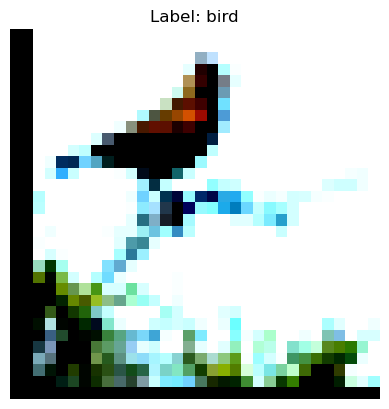

In [23]:
import random  # Import the random module
import torch
import matplotlib.pyplot as plt

# Assuming 'train' is defined and contains your dataset
classes = train.dataset.classes  # Fetch the class names

# Pick a random example from the training set
selection = random.randrange(len(train))  # Pick a random index
image, label = train[selection]  # Get the selected image and its label

# Function to display the image
def show_cifar_img(image, label, classes):
    # Convert the image tensor to a numpy array
    image = image.permute(1, 2, 0).numpy()  # Change from (C, H, W) to (H, W, C)
    plt.imshow(image)
    plt.title(f"Label: {classes[label]}")  # Show the label
    plt.axis('off')  # Hide the axis
    plt.show()  # Display the image

# Show the selected image and label
show_cifar_img(image, label, classes)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the device (GPU/CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 3 * 3, 256)  
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)  

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = F.relu(x)
        x = self.fc2(x)  
        return x  

def fit(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()  # Clear gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights

            running_loss += loss.item()  # Accumulate loss
            _, predicted = torch.max(outputs.data, 1)  # Get predictions
            total_train += labels.size(0)  # Total examples
            correct_train += (predicted == labels).sum().item()  # Count correct predictions

        # Average loss and accuracy for the current epoch
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct_train / total_train
        history['train_loss'].append(epoch_loss)
        history['train_accuracy'].append(epoch_accuracy)

        # Validate model
        model.eval()  # Set to evaluation mode
        val_loss = 0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()  # Accumulate validation loss
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        # Average validation loss and accuracy
        val_loss_average = val_loss / len(val_loader)
        epoch_val_accuracy = 100 * correct_val / total_val

        # Store the results in history
        history['val_loss'].append(val_loss_average)
        history['val_accuracy'].append(epoch_val_accuracy)

        # Print progress
        print(f'Epoch [{epoch + 1}/{num_epochs}], '
              f'Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%, '
              f'Val Loss: {val_loss_average:.4f}, Val Accuracy: {epoch_val_accuracy:.2f}%')

    return history

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and create datasets
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
val_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Hyperparameters
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
NUM_EPOCHS = 20

# Instantiate the model and send it to the device
model = CNN().to(DEVICE)

# Set Loss function with criterion
criterion = nn.CrossEntropyLoss()

# Set optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Training step
history = fit(
    model,
    train_loader=train_loader,  
    val_loader=val_loader,      
    device=DEVICE,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS
)

Epoch [1/20], Train Loss: 0.1467, Train Accuracy: 95.54%, Val Loss: 0.0470, Val Accuracy: 98.46%
Epoch [2/20], Train Loss: 0.0542, Train Accuracy: 98.41%, Val Loss: 0.0288, Val Accuracy: 99.09%
Epoch [3/20], Train Loss: 0.0432, Train Accuracy: 98.61%, Val Loss: 0.0320, Val Accuracy: 98.99%
Epoch [4/20], Train Loss: 0.0348, Train Accuracy: 98.95%, Val Loss: 0.0195, Val Accuracy: 99.36%
Epoch [5/20], Train Loss: 0.0313, Train Accuracy: 99.03%, Val Loss: 0.0252, Val Accuracy: 99.20%
Epoch [6/20], Train Loss: 0.0259, Train Accuracy: 99.15%, Val Loss: 0.0266, Val Accuracy: 99.23%
Epoch [7/20], Train Loss: 0.0243, Train Accuracy: 99.24%, Val Loss: 0.0226, Val Accuracy: 99.23%
Epoch [8/20], Train Loss: 0.0219, Train Accuracy: 99.29%, Val Loss: 0.0412, Val Accuracy: 98.83%
Epoch [9/20], Train Loss: 0.0209, Train Accuracy: 99.36%, Val Loss: 0.0242, Val Accuracy: 99.24%
Epoch [10/20], Train Loss: 0.0169, Train Accuracy: 99.48%, Val Loss: 0.0207, Val Accuracy: 99.37%
Epoch [11/20], Train Loss: 0.

### 6. Training

In [ ]:
model, history = fit(
    model,
    train_loader = train_loader,
    val_loader = val_loader,
    device = DEVICE,
    optimizer = optimizer,
    criterion = criterion,
    num_epochs = NUM_EPOCHS
)

### 7. Plot loss and accuracy

Number of epochs recorded: 20
Training losses: [0.13162525116241594, 0.05226780628274902, 0.0409766246350224, 0.03375036385394871, 0.02814899188747976, 0.026194286881930512, 0.022695141294953734, 0.022092662039235843, 0.018548453292836234, 0.018886197245367536, 0.017196584720912178, 0.017226953171836024, 0.014948759934976824, 0.014337998035313961, 0.013777176939167092, 0.012671691110563479, 0.01393434897442985, 0.01236498727904952, 0.011572603367685026, 0.012756092170190286]
Validation losses: [0.035729239295164195, 0.0307090347010486, 0.030117251013982507, 0.024174231538118138, 0.02788678297376209, 0.02976028761758284, 0.02426673428350102, 0.0223818411099256, 0.028004023257444773, 0.022701774893964174, 0.018670575992986136, 0.01984326364388771, 0.029583293091614313, 0.0239385157134183, 0.025454933891498634, 0.020016690751494978, 0.02553696541543446, 0.0208930408210247, 0.03228955633558998, 0.020659078990465814]
Training accuracy: [95.91666666666667, 98.47, 98.74666666666667, 98.973333

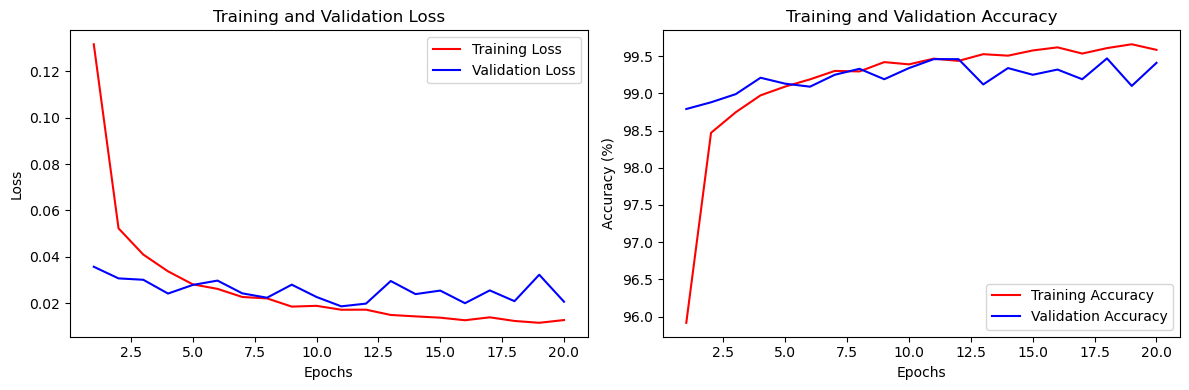

In [33]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Adding debugging prints
    print(f"Number of epochs recorded: {len(history['train_loss'])}")
    print(f"Training losses: {history['train_loss']}")
    print(f"Validation losses: {history['val_loss']}")
    print(f"Training accuracy: {history['train_accuracy']}")
    print(f"Validation accuracy: {history['val_accuracy']}")
    
    plt.figure(figsize=(12, 4))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'b', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accuracy'], 'r', label='Training Accuracy')
    plt.plot(epochs, history['val_accuracy'], 'b', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function after training
plot_training_history(history)

### 8. Evaluate

Evaluate on training data, validation data and testing data.

TypeError: only integer tensors of a single element can be converted to an index

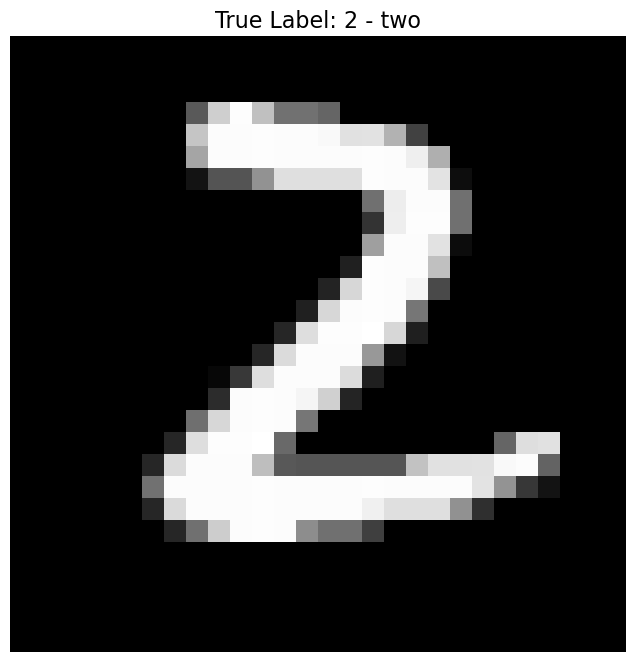

<Figure size 1000x600 with 0 Axes>

In [19]:
def evaluate(model: nn.Module, data_loader: DataLoader, device, criterion: nn.Module) -> dict:
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # No gradient calculations for evaluation
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)  # Get predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    

    # Calculate average loss and accuracy
    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total

    return {"loss": avg_loss, "accuracy": accuracy}
# Get a single image and its label from the test dataset
index = np.random.randint(len(test))  # Randomly select an index
image, label = test[index]

# Prepare the image for prediction
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    input_image = image.unsqueeze(0).to(device)                     # Add batch dimension and move to device
    outputs = model(input_image)                                    # Get model predictions
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)  # Apply softmax to get probabilities

plot_probabilities(
    image = image,
    label = label,
    probabilities = probabilities, 
    classes = test.classes,
    n = 5
)
evaluate(
    model = model,
    data_loader = val_loader,  # evaluate on validation data
    device = device,
    criterion = criterion,
    flatten = False
)
evaluate(
    model = model,
    data_loader = test_loader,  # evaluate on testing data
    device = device,
    criterion = criterion,
    flatten = False
)
test_loader = DataLoader(TensorDataset(test_data, test_labels), batch_size=64, shuffle=False)